\nBudget B = 8\n
Transformed Graph Edges (weight=1 only):
3 -- 4, weight=1
3 -- 12, weight=1
3 -- 5, weight=1
4 -- 12, weight=1
4 -- 5, weight=1
12 -- 15, weight=1
5 -- 15, weight=1
15 -- 8, weight=1
9 -- 11, weight=1
9 -- 1, weight=1
9 -- 13, weight=1
11 -- 10, weight=1
11 -- 7, weight=1
1 -- 10, weight=1
1 -- 2, weight=1
13 -- 6, weight=1
13 -- 0, weight=1
10 -- 2, weight=1
7 -- 14, weight=1
7 -- 0, weight=1
8 -- 6, weight=1
8 -- 14, weight=1
6 -- 2, weight=1
14 -- 0, weight=1


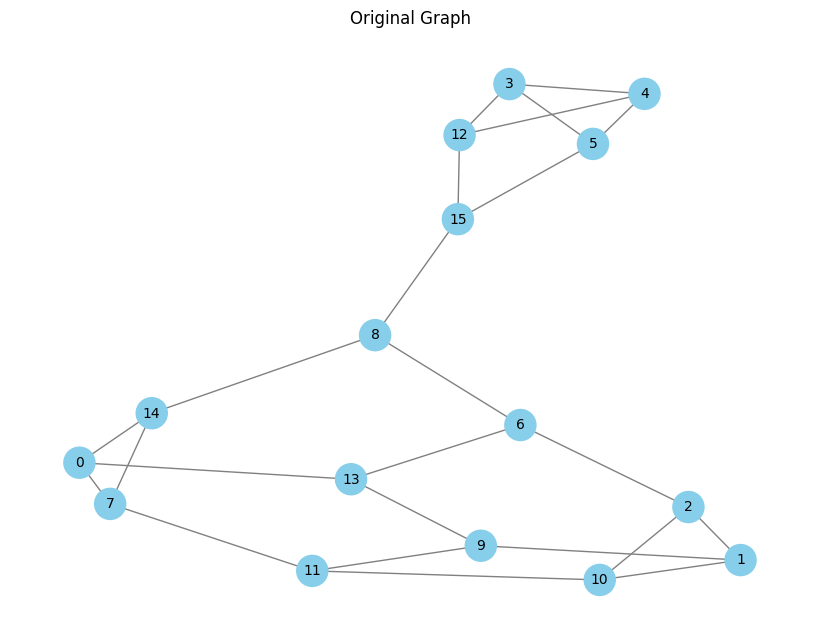

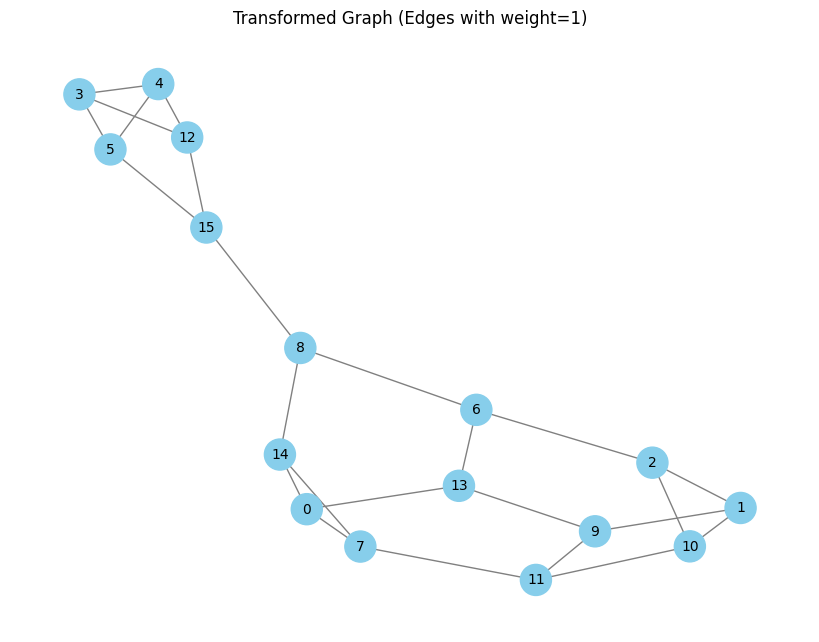

\n=== Brute-Force Result ===
Centers: (3, 4, 12, 5, 15, 9, 7, 2)
Total Cost: 8
Feasible under B=8: YES


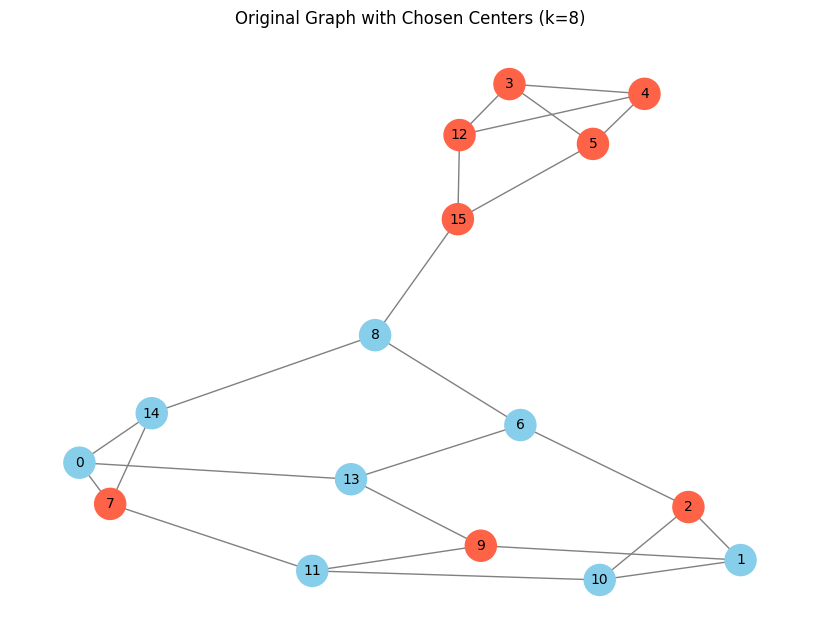

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import pandas as pd

def load_graph_from_csv(filename):
    g = nx.Graph()
    with open(filename, 'r') as f:
        for line in f:
            nodes = line.strip().split(',')
            if len(nodes) == 2:
                g.add_edge(int(nodes[0]), int(nodes[1]))
            elif len(nodes) == 1:
                g.add_node(int(nodes[0]))
    return g

def transform_dominating_to_minsum(g, k):
    g_prime = nx.Graph()
    nodes = list(g.nodes())
    for i, u in enumerate(nodes):
        for v in nodes[i+1:]:
            if g.has_edge(u, v):
                g_prime.add_edge(u, v, weight=1)
            else:
                g_prime.add_edge(u, v, weight=999)
    b = len(g.nodes()) - k
    return g_prime, k, b

def compute_min_sum(g_prime, centers):
    total = 0
    for v in g_prime.nodes():
        if v in centers:
            continue
        try:
            dists = [nx.shortest_path_length(g_prime, v, s, weight='weight') for s in centers]
            total += min(dists)
        except:
            total += 999
    return total

def find_best_centers(g_prime, k, b):
    best = None
    best_cost = float('inf')
    for centers in itertools.combinations(g_prime.nodes(), k):
        cost = compute_min_sum(g_prime, centers)
        if cost <= b and cost < best_cost:
            best = centers
            best_cost = cost
    return best, best_cost

def visualize_graph(g, title, highlight_nodes=None):
    pos = nx.spring_layout(g, seed=42)
    plt.figure(figsize=(8, 6))
    node_colors = ['tomato' if highlight_nodes and node in highlight_nodes else 'skyblue' for node in g.nodes()]
    nx.draw(g, pos, with_labels=True, node_color=node_colors, edge_color='gray', node_size=500, font_size=10)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Parameters
filename = "input_16 vertices.csv"
k = 8

# Run process
g = load_graph_from_csv(filename)
g_prime, k_prime, b = transform_dominating_to_minsum(g, k)
print(f"\\nBudget B = {b}\\n")

print("Transformed Graph Edges (weight=1 only):")
for u, v, d in g_prime.edges(data=True):
    if d['weight'] == 1:
        print(f"{u} -- {v}, weight=1")

visualize_graph(g, "Original Graph")

# Create and show a filtered version of the transformed graph (only weight-1 edges)
g_prime_filtered = nx.Graph()
g_prime_filtered.add_edges_from([(u, v) for u, v, d in g_prime.edges(data=True) if d['weight'] == 1])
g_prime_filtered.add_nodes_from(g_prime.nodes())

visualize_graph(g_prime_filtered, "Transformed Graph (Edges with weight=1)")

centers, cost = find_best_centers(g_prime, k, b)
print("\\n=== Brute-Force Result ===")
if centers:
    print(f"Centers: {centers}")
    print(f"Total Cost: {cost}")
    print(f"Feasible under B={b}: {'YES' if cost <= b else 'NO'}")
else:
    print("No feasible k-center found under budget.")

# Final visualization on the original graph
if centers:
    visualize_graph(g, f"Original Graph with Chosen Centers (k={k})", highlight_nodes=centers)
